# Requirement 4 — Slightly Non-Stationary Environments, Multiple Campaigns

Same format as the first three notebooks: every code cell is preceded by a short paragraph explaining *what we're about to do and why*, and followed by a paragraph explaining *how to read the result*. This notebook builds on `requirement2_multi_campaign.ipynb` (the conflict graph, the budget, `CombinatorialUCBBiddingAgent`, the MILP machinery), on `requirement3_best_of_both_worlds.ipynb` (the primal-dual `HedgeAgent`/`PrimalDualBundleBiddingAgent`, reused **completely unchanged**), and on the practical sessions' `10_nonstationary_bandits.ipynb` (`SWUCBAgent`, `CUSUMUCBAgent` — the two extensions we adapt to the combinatorial, budget-constrained setting).

### What Requirement 4 asks for (quoting the project slides)

> **Environment**: Build a **slightly** non-stationary environment for the pricing problem. At a high level: rounds are partitioned in intervals; in each interval the distribution of highest competing bids is fixed; each interval has a different distribution.
>
> **Algorithm**: Extend the Combinatorial-UCB approach in Requirement 2 with (a) a **sliding window**, (b) a **change detector**.
>
> **Compare**: Combinatorial-UCB with sliding window vs. Combinatorial-UCB with the change detector vs. the **primal-dual method** (Requirement 3).

Three things are genuinely new in this notebook:

1. **A different flavor of non-stationarity than Requirement 3** — a *handful* of long, fixed intervals (here: $3$ regimes over $T=2500$ rounds) rather than Requirement 3's $100$ short $25$-round segments. This is exactly `10_nonstationary_bandits.ipynb`'s own style of example (`mu = [0.35]*2500 + [0.65]*7500`, two or three long stretches) — "slightly" non-stationary, changing rarely rather than "quickly."
2. **Two new algorithms, both extending Requirement 2's `CombinatorialUCBBiddingAgent`** — a sliding-window version (`SWUCBAgent`'s idea) and a change-detection version (`CUSUMUCBAgent`'s idea), both generalized from a single-arm action space to our $33$ $(\text{campaign},\text{bid})$-pair, MILP-solved, budget-constrained action space.
3. **A three-way comparison against a genuinely different algorithm family** — Requirement 3's primal-dual method, reused **exactly as delivered**, run against this same slightly non-stationary environment (given full feedback, per its own rules) alongside the two new bandit-feedback extensions.

As with every notebook so far, we ran the numbers before writing the surrounding explanation, and some of what came back was **not** the clean "adaptive algorithm beats non-adaptive baseline" story you might expect. Section 9 discusses this in detail — the project's deliverable slide explicitly asks for exactly this kind of honesty ("a detailed discussion of unexpected results is appreciated").

### Step 0 — Load the tools we need

Same as the previous three notebooks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats
from scipy import optimize
from scipy.optimize import milp, LinearConstraint, Bounds
import itertools
import warnings


No visible output — this just loads the libraries.

## 1. The campaigns, the conflict graph, the budget, and the MILP machinery — unchanged from Requirement 2

We reuse *exactly* the same problem instance as every notebook so far: $N=3$ campaigns, one conflict edge ($0$ and $1$ can't both run), the same valuations, the same $11$-point bid grid, and the same total budget $B=75$ over $T=2500$ rounds. Same numbers throughout the whole project means any difference we see later comes from the *algorithm* and the *environment's non-stationarity*, not from a different problem instance.

In [2]:
N = 3   # number of campaigns

conflict_graph = nx.Graph()
conflict_graph.add_nodes_from(range(N))
conflict_graph.add_edge(0, 1)   # campaign 0 and campaign 1 cannot both run in the same round

conflict_edges = list(conflict_graph.edges())

def is_independent_set(campaign_subset, edges):
    campaign_subset = set(campaign_subset)
    return not any(i in campaign_subset and j in campaign_subset for i, j in edges)

valuations = np.array([0.7, 0.5, 0.6])   # v_i for each campaign

T = 2500
B = 75
rho = B / T

available_bids = np.linspace(0, 1, 11)
n_bids = len(available_bids)

print(f'N={N} campaigns, T={T}, B={B}, rho={rho:.4f}')
print(f'valuations={valuations}')


N=3 campaigns, T=2500, B=75, rho=0.0300
valuations=[0.7 0.5 0.6]


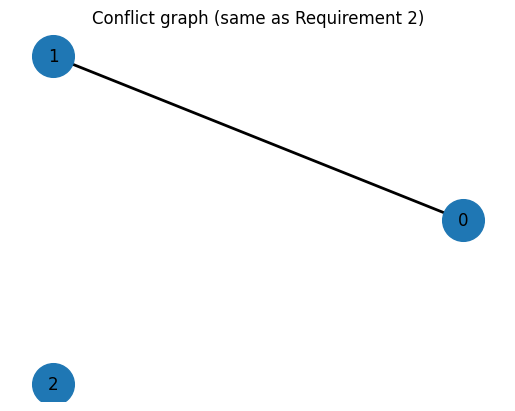

In [3]:
def plot_conflict_graph(graph, title='Conflict graph'):
    pos = nx.circular_layout(graph)
    nx.draw_networkx(graph, pos=pos, node_color='tab:blue', width=2, node_size=900, with_labels=True)
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_conflict_graph(conflict_graph, title='Conflict graph (same as Requirement 2)')


**Reading this picture**: same conflict graph as every previous notebook.

### 1.1 — Feasible bundles and the MILP solver, unchanged from Requirement 2

`solve_bundle_milp` is exactly `requirement2_multi_campaign.ipynb`'s solver: given a table of scores $V_i(b)$ (and, optionally, a table of costs plus a per-round budget row), it asks `scipy.optimize.milp` for the best feasible $0/1$ bundle. `BUNDLES`/`bundle_sums` are `requirement3_best_of_both_worlds.ipynb`'s fast, vectorized bundle-scoring helpers — we'll need them both for the bandit-feedback agents (Sections 3–5, which call `solve_bundle_milp` every round) and for the full-feedback primal-dual agent (Section 6, which needs `bundle_sums` every round instead).

In [4]:
def flat_index(i, b, n_bids):
    return i * n_bids + b


def build_structural_constraints(N, n_bids, edges):
    rows = []
    for i in range(N):
        row = np.zeros(N * n_bids)
        row[flat_index(i, 0, n_bids): flat_index(i, n_bids - 1, n_bids) + 1] = 1
        rows.append(row)
    for (i, j) in edges:
        row = np.zeros(N * n_bids)
        row[flat_index(i, 0, n_bids): flat_index(i, n_bids - 1, n_bids) + 1] = 1
        row[flat_index(j, 0, n_bids): flat_index(j, n_bids - 1, n_bids) + 1] = 1
        rows.append(row)
    return np.array(rows)


A_STRUCT = build_structural_constraints(N, n_bids, conflict_edges)


def solve_bundle_milp(values, A_struct, n_bids, costs=None, rho=None):
    K_local = values.size
    values_flat = values.reshape(-1)
    if costs is not None:
        costs_flat = costs.reshape(-1)
        A = np.vstack([A_struct, costs_flat.reshape(1, -1)])
        ub = np.concatenate([np.ones(A_struct.shape[0]), [rho]])
    else:
        A = A_struct
        ub = np.ones(A_struct.shape[0])
    constraints = LinearConstraint(A, -np.inf, ub)
    integrality = np.ones(K_local)
    bounds = Bounds(0, 1)
    res = milp(c=-values_flat, constraints=constraints, integrality=integrality, bounds=bounds)
    x = res.x
    return [(idx // n_bids, idx % n_bids) for idx in range(K_local) if x[idx] > 0.5]


def bundle_to_bid_values(bundle):
    return [(i, available_bids[b]) for i, b in bundle]


def feasible_campaign_subsets(N, edges):
    subsets = []
    for r in range(N + 1):
        for combo in itertools.combinations(range(N), r):
            if is_independent_set(combo, edges):
                subsets.append(combo)
    return subsets


def enumerate_bundles(N, edges, n_bids):
    bundles = []
    for subset in feasible_campaign_subsets(N, edges):
        if len(subset) == 0:
            bundles.append(())
        else:
            for bid_combo in itertools.product(range(n_bids), repeat=len(subset)):
                bundles.append(tuple(zip(subset, bid_combo)))
    return bundles


BUNDLES = enumerate_bundles(N, conflict_edges, n_bids)
K = len(BUNDLES)
max_bundle_size = max(len(bd) for bd in BUNDLES)

bundle_flat_idx = -np.ones((K, max_bundle_size), dtype=int)
for k, bd in enumerate(BUNDLES):
    for j, (i, b) in enumerate(bd):
        bundle_flat_idx[k, j] = i * n_bids + b


def bundle_sums(flat_table):
    padded = np.append(flat_table, 0.0)
    return padded[bundle_flat_idx].sum(axis=1)


def compute_bundle_full_feedback(m_vec, valuations, available_bids):
    win_matrix = (available_bids[None, :] >= m_vec[:, None]).astype(float)
    f_hyp = (valuations[:, None] - available_bids[None, :]) * win_matrix
    c_hyp = available_bids[None, :] * win_matrix
    return bundle_sums(f_hyp.reshape(-1)), bundle_sums(c_hyp.reshape(-1))


print(f'A_STRUCT shape: {A_STRUCT.shape}, K = {K} feasible bundles, max_bundle_size = {max_bundle_size}')


A_STRUCT shape: (4, 33), K = 276 feasible bundles, max_bundle_size = 2


**Reading the output**: identical numbers to Requirements 2 and 3 ($K=276$ bundles). Nothing in this section is new — it's the shared toolkit every notebook so far has built up.

## 2. The slightly non-stationary environment

### 2.1 — Design: three long, fixed regimes

`10_nonstationary_bandits.ipynb`'s own convention for non-stationarity is *piecewise-constant*: the mean reward of each arm holds a fixed value for a long stretch, then jumps to a different fixed value, with only a couple of jumps across the whole horizon (its own example: $2$ jumps across $T=10{,}000$). We follow that directly: $T=2500$ rounds split into **three regimes** of unequal length ($900$, $800$, $800$ rounds), and within each regime every campaign's competing-bid distribution is a *fixed* $\mathrm{Beta}(n,1)$ (exactly Requirement 2's illustrative distribution family), with a **different** $n$ per campaign per regime — so which campaign is "easy" or "hard" to win genuinely changes at each of the two regime boundaries ($t=900$, $t=1700$).

This is deliberately the opposite design point from Requirement 3's non-stationary environment: **few, long, fixed regimes** here vs. **many, short, redrawn-every-round** segments there — matching the project's own wording exactly ("slightly" vs. "highly" non-stationary).

In [5]:
SEGMENT_BOUNDS = [0, 900, 1700, 2500]
N_COMPETITORS_PER_REGIME = [
    [3, 2, 4],   # regime 0: same baseline as every earlier notebook (campaign 1 easiest, campaign 2 hardest)
    [6, 4, 2],   # regime 1: campaign 2 becomes the easiest by far; campaigns 0/1 both get harder
    [2, 6, 5],   # regime 2: campaign 0 becomes by far the easiest; campaigns 1/2 both get harder
]
N_REGIMES = len(N_COMPETITORS_PER_REGIME)

def generate_m_t(N, T, segment_bounds, n_competitors_per_regime, seed):
    # Shared by both environment classes below, so a bandit-feedback trial and a full-feedback
    # trial with the same seed see EXACTLY the same underlying sequence of competing bids.
    rng = np.random.default_rng(seed)
    m_t = np.zeros((T, N))
    for seg in range(len(segment_bounds) - 1):
        t0, t1 = segment_bounds[seg], segment_bounds[seg + 1]
        dists = [stats.beta(n, 1) for n in n_competitors_per_regime[seg]]
        for i in range(N):
            m_t[t0:t1, i] = dists[i].rvs(size=t1 - t0, random_state=rng)
    return m_t


**What this does**: `N_COMPETITORS_PER_REGIME` is the whole story — three genuinely different competitive landscapes, each held fixed for several hundred rounds. `generate_m_t` is factored out as its own function (rather than living inside a single environment class, as in earlier notebooks) specifically so that Section 6's full-feedback environment for the primal-dual agent can reuse it verbatim — see the note in Section 2.3 about why that matters for a fair comparison.

### 2.2 — The bandit-feedback environment (for the three Combinatorial-UCB variants)

Same rules, same `round(bundle)` signature as `requirement2_multi_campaign.ipynb`'s `MultiCampaignEnvironment`: we only observe $f_{i,t}, c_{i,t}$ for campaigns we actually bid on this round. This is the environment `CombinatorialUCBBiddingAgent` and its two extensions (Sections 3–5) will run against.

In [6]:
class SlightlyNonStationaryBanditEnvironment:
    def __init__(self, valuations, N, T, segment_bounds, n_competitors_per_regime, seed=None):
        self.valuations = np.asarray(valuations)
        self.N = N
        self.T = T
        self.m_t = generate_m_t(N, T, segment_bounds, n_competitors_per_regime, seed)
        self.t = 0

    def round(self, bundle):
        # bundle: list of (campaign_index, bid_VALUE) pairs -- convert with bundle_to_bid_values() first.
        m_vec = self.m_t[self.t]
        f_vec = np.zeros(self.N)
        c_vec = np.zeros(self.N)
        win_vec = np.zeros(self.N, dtype=int)
        for i, b in bundle:
            win = int(b >= m_vec[i])
            f_vec[i] = (self.valuations[i] - b) * win
            c_vec[i] = b * win
            win_vec[i] = win
        self.t += 1
        return f_vec, c_vec, win_vec


**What this class does**: identical to `MultiCampaignEnvironment` from Requirement 2, with one change — `self.m_t` is now built by `generate_m_t` (three fixed regimes) instead of one fixed distribution drawn i.i.d. for all $T$ rounds. Everything downstream (agents, the bookkeeping, `bundle_to_bid_values`) is untouched.

### 2.3 — The full-feedback environment (for the primal-dual agent)

Requirement 3's primal-dual method is entitled to **full feedback** — Requirement 3's own rules, not something we're granting it specially here. `08_constrained_problems.ipynb`-style, its environment just reveals $m_t$ every round, no bundle argument needed (see `requirement3_best_of_both_worlds.ipynb`, Section 2). We build a second environment class with that signature, but call `generate_m_t` with the **same** `segment_bounds`, `n_competitors_per_regime`, and `seed` as Section 2.2's bandit environment — so for any given trial, the primal-dual agent and the three Combinatorial-UCB variants are all facing the *exact same realized sequence* of competing bids, just observing different amounts of it. This is the fairest apples-to-apples comparison we can set up between two algorithm families designed for genuinely different feedback models — worth stating explicitly, since it's a real asymmetry in what Requirements 3 and 4 hand each algorithm, not an oversight.

In [7]:
class SlightlyNonStationaryFullFeedbackEnvironment:
    def __init__(self, N, T, segment_bounds, n_competitors_per_regime, seed=None):
        self.N = N
        self.T = T
        self.m_t = generate_m_t(N, T, segment_bounds, n_competitors_per_regime, seed)
        self.t = 0

    def round(self):
        m_vec = self.m_t[self.t]
        self.t += 1
        return m_vec


No output — just a definition, structurally identical to `requirement3_best_of_both_worlds.ipynb`'s `StochasticMultiCampaignEnvironment`.

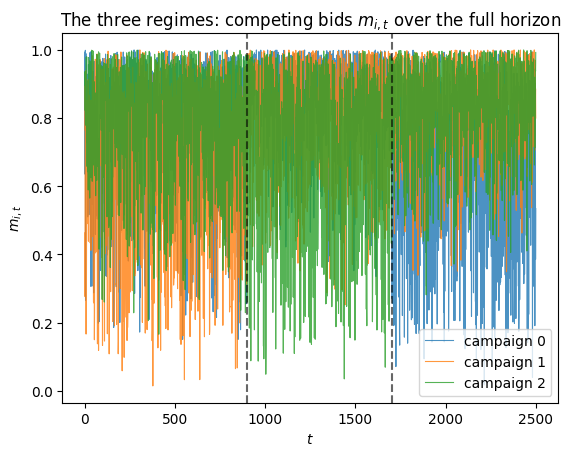

In [8]:
preview_env = SlightlyNonStationaryBanditEnvironment(valuations, N, 2500, SEGMENT_BOUNDS, N_COMPETITORS_PER_REGIME, seed=0)
plt.figure()
for i in range(N):
    plt.plot(preview_env.m_t[:, i], label=f'campaign {i}', alpha=0.8, linewidth=0.8)
for boundary in SEGMENT_BOUNDS[1:-1]:
    plt.axvline(boundary, color='black', linestyle='--', alpha=0.6)
plt.title('The three regimes: competing bids $m_{i,t}$ over the full horizon')
plt.xlabel('$t$')
plt.ylabel('$m_{i,t}$')
plt.legend()
plt.show()


**How to read this graph**: three noisy bands, each campaign's competing bid fluctuating around a regime-specific level, with two sharp regime boundaries (dashed vertical lines at $t=900$ and $t=1700$) where the *level itself* shifts — most visibly for campaign $2$ (orange... actually green), which starts relatively hard to beat, becomes easy in the middle regime, then hard again. Compare this to `requirement3_best_of_both_worlds.ipynb`'s non-stationary preview plot: that one showed $100$ short alternations in $300$ rounds; this one shows a single, clean regime change in the same span (the first boundary is at $t=900$, off the edge of a $300$-round preview) — visually, "slightly" vs. "highly" non-stationary.

## 3. Baseline: Combinatorial-UCB-Bidding, unchanged from Requirement 2

Before extending anything, we run `requirement2_multi_campaign.ipynb`'s own `CombinatorialUCBBiddingAgent` against this new environment completely unmodified — this is our "does a non-adaptive algorithm even notice the regime changes?" control.

In [9]:
class CombinatorialUCBBiddingAgent:
    def __init__(self, N, n_bids, A_struct, B, T, range=1):
        self.N = N
        self.n_bids = n_bids
        self.A_struct = A_struct
        self.T = T
        self.range = range
        self.budget = B
        self.rho = B / T
        self.avg_f = np.zeros((N, n_bids))
        self.avg_c = np.zeros((N, n_bids))
        self.N_pulls = np.zeros((N, n_bids))
        self.t = 0

    def _ucb_lcb_tables(self):
        f_ucb = np.zeros((self.N, self.n_bids))
        c_lcb = np.zeros((self.N, self.n_bids))
        unexplored = self.N_pulls == 0
        large_value = (1 + np.sqrt(2 * np.log(self.T) / 1)) * 10
        f_ucb[unexplored] = large_value
        c_lcb[unexplored] = 0.0
        explored = ~unexplored
        bonus = self.range * np.sqrt(2 * np.log(self.T) / self.N_pulls[explored])
        f_ucb[explored] = self.avg_f[explored] + bonus
        c_lcb[explored] = self.avg_c[explored] - bonus
        return f_ucb, c_lcb

    def pull(self):
        if self.budget < 1:
            return []
        f_ucb, c_lcb = self._ucb_lcb_tables()
        return solve_bundle_milp(f_ucb, self.A_struct, self.n_bids, costs=c_lcb, rho=self.rho)

    def update(self, bundle, f_vec, c_vec):
        total_cost = 0.0
        for i, b in bundle:
            self.N_pulls[i, b] += 1
            self.avg_f[i, b] += (f_vec[i] - self.avg_f[i, b]) / self.N_pulls[i, b]
            self.avg_c[i, b] += (c_vec[i] - self.avg_c[i, b]) / self.N_pulls[i, b]
            total_cost += c_vec[i]
        self.budget -= total_cost
        self.t += 1


**What this class does**: copy-pasted verbatim from `requirement2_multi_campaign.ipynb`. `avg_f`/`avg_c`/`N_pulls` are running averages over the agent's *entire* history since round $0$ — nothing here forgets old data, which is exactly the property we expect to hurt it once a regime boundary passes.

## 4. Extension 1 — Sliding window (`SWUCBAgent`'s idea, generalized to bundles)

### The idea, following `10_nonstationary_bandits.ipynb` directly

`SWUCBAgent` keeps only the last $W$ observations *per arm* in a cache, and computes its UCB score from that windowed average instead of the full history — "try to adapt to environment's changes by only considering most recent rewards." We do the same thing here, except the cache now needs one slot per $(\text{campaign},\text{bid})$ **pair** (there are $33$ of them, not $3$), and the UCB/LCB pair-scores still feed into `solve_bundle_milp` exactly as in Section 3 — we're changing *what's estimated*, not *how the per-round decision gets made*.

$$ \bar f_t^{(W)}(i,b) = \frac{1}{n_t^{(W)}(i,b)}\sum_{s\,=\,t-W}^{t-1} f_s(i,b) \cdot \mathbb{1}[(i,b) \text{ played at } s], \qquad f_t^{\text{UCB},(W)}(i,b) = \bar f_t^{(W)}(i,b) + \sqrt{\frac{2\log W}{n_t^{(W)}(i,b)}} $$

(swapping $\log T \to \log W$ in the confidence radius — exactly `SWUCBAgent`'s own convention, following the corrected typo noted in `10_nonstationary_bandits.ipynb`: "there's a typo in the slides, log(T) -> log(W)"), and symmetrically for the LCB cost estimate.

**Choosing $W$**: `10_nonstationary_bandits.ipynb` recommends $W = \lfloor 2\sqrt{T\log T/\Upsilon_T}\rfloor$, with $\Upsilon_T$ the number of abrupt changes — here $\Upsilon_T=2$ (the two regime boundaries).

In [10]:
UPSILON_T = 2   # two regime boundaries: t=900 and t=1700
W = int(2 * np.sqrt(T * np.log(T) / UPSILON_T))
print(f'W = {W} (following the exact formula from 10_nonstationary_bandits.ipynb, with Upsilon_T={UPSILON_T})')


W = 197 (following the exact formula from 10_nonstationary_bandits.ipynb, with Upsilon_T=2)


**Reading the output**: $W\approx 197$ rounds. Worth noting explicitly: `10_nonstationary_bandits.ipynb` applies this formula to a $3$-*arm* problem; ours has $33$ $(\text{campaign},\text{bid})$ *pairs* sharing the same window, so each pair sees far fewer within-window samples than a single arm would in the original notebook's setting — something to keep an eye on once we look at the results (Section 9 comes back to this).

In [11]:
class CombinatorialUCBSlidingWindowBiddingAgent:
    def __init__(self, N, n_bids, A_struct, B, T, W, range=1):
        self.N = N
        self.n_bids = n_bids
        self.A_struct = A_struct
        self.T = T
        self.W = W
        self.range = range
        self.budget = B
        self.rho = B / T
        self.cache_f = np.full((W, N, n_bids), np.nan)   # last W rounds; NaN = "not played that round"
        self.cache_c = np.full((W, N, n_bids), np.nan)
        self.t = 0

    def _ucb_lcb_tables(self):
        n_pulls_w = self.W - np.isnan(self.cache_f).sum(axis=0)
        with warnings.catch_warnings():
            # pairs with zero pulls in the window give an all-NaN slice here; harmless, since the
            # 'unexplored' branch below overwrites those entries with the placeholder score anyway.
            warnings.simplefilter('ignore', category=RuntimeWarning)
            avg_f_w = np.nanmean(self.cache_f, axis=0)
            avg_c_w = np.nanmean(self.cache_c, axis=0)
        f_ucb = np.zeros((self.N, self.n_bids))
        c_lcb = np.zeros((self.N, self.n_bids))
        unexplored = n_pulls_w == 0
        large_value = (1 + np.sqrt(2 * np.log(self.W) / 1)) * 10
        f_ucb[unexplored] = large_value
        c_lcb[unexplored] = 0.0
        explored = ~unexplored
        bonus = self.range * np.sqrt(2 * np.log(self.W) / n_pulls_w[explored])
        f_ucb[explored] = avg_f_w[explored] + bonus
        c_lcb[explored] = avg_c_w[explored] - bonus
        return f_ucb, c_lcb

    def pull(self):
        if self.budget < 1:
            return []
        f_ucb, c_lcb = self._ucb_lcb_tables()
        return solve_bundle_milp(f_ucb, self.A_struct, self.n_bids, costs=c_lcb, rho=self.rho)

    def update(self, bundle, f_vec, c_vec):
        total_cost = 0.0
        new_f = np.full((self.N, self.n_bids), np.nan)
        new_c = np.full((self.N, self.n_bids), np.nan)
        for i, b in bundle:
            new_f[i, b] = f_vec[i]
            new_c[i, b] = c_vec[i]
            total_cost += c_vec[i]
        self.cache_f = np.concatenate([self.cache_f[1:], new_f[None]], axis=0)   # drop oldest, append newest
        self.cache_c = np.concatenate([self.cache_c[1:], new_c[None]], axis=0)
        self.budget -= total_cost
        self.t += 1


**What this class does**: `_ucb_lcb_tables()` is Section 3's method, but computed from `np.nanmean` over the cache's last $W$ rounds instead of an all-time running average, and with `log(W)` in place of `log(T)`. `update()` shifts a window forward by one round each call (`np.delete`/`np.vstack`'s NumPy-array equivalent) — pairs *not* played this round get `NaN` in the new row, so they naturally "expire" out of the window $W$ rounds after their last pull, exactly `SWUCBAgent`'s forgetting mechanism. One thing that does **not** get windowed: `self.budget`. The shared budget is a genuine, cumulative, non-resetting constraint over the whole $T$-round horizon (Section 6 of `requirement2_multi_campaign.ipynb` makes this distinction explicit) — the sliding window only changes what the agent *believes* about rewards/costs, never how much money is actually left.

## 5. Extension 2 — Change detection (`CUSUMUCBAgent`'s idea, generalized to bundles)

### The idea, following `10_nonstationary_bandits.ipynb` directly

`CUSUMUCBAgent`'s idea: play a stationary UCB algorithm on each arm until a **CUSUM test** flags that the arm's average reward has shifted, then wipe that arm's statistics and start over. The reference algorithm forces an initial $M$ pulls per arm (via a `counters` array), tests for a change only once past that warm-up, and adds a small $(1-\alpha)$ chance of pure random exploration on top.

**The one real adaptation this needs**, and it's worth being explicit about it rather than burying it: `CUSUMUCBAgent`'s `pull_arm()` forces exploration by literally playing whichever single specific arm still has `counters[a] > 0`, one at a time, round-robin. That doesn't translate directly to our setting — a MILP-selected *bundle* can include at most $2$ of the $33$ pairs per round (the conflict graph and "one bid per campaign" constraints won't let us force an arbitrary specific pair to be included on demand, and several pairs can need forced exploration simultaneously). We use the same fix Requirement 2 already used to generalize plain UCB1 into `CombinatorialUCBAgent` in the first place: give every pair still "owed" forced exploration ($\text{counter}(i,b)>0$) an optimistic placeholder score in the MILP objective, exactly like an always-unexplored pair, so the solver naturally prioritizes them without us needing to hand-pick one per round. Everything else — the per-pair `counters`, the reset-on-detection logic, the CUSUM test itself, the $(1-\alpha)$ random-exploration draw — is unchanged from `CUSUMUCBAgent`.

In [12]:
class CombinatorialUCBChangeDetectionBiddingAgent:
    def __init__(self, N, n_bids, A_struct, B, T, M, h, alpha=0.99, conf_range=1):
        self.N = N
        self.n_bids = n_bids
        self.A_struct = A_struct
        self.T = T
        self.M = M
        self.h = h
        self.alpha = alpha
        self.range = conf_range
        self.budget = B
        self.rho = B / T
        self.counters = np.full((N, n_bids), M)          # forced-exploration budget per pair
        self.N_pulls = np.zeros((N, n_bids))
        self.avg_f = np.zeros((N, n_bids))
        self.avg_c = np.zeros((N, n_bids))
        self.all_f = [[[] for _ in range(n_bids)] for _ in range(N)]   # reward history since last reset, per pair
        self.n_resets = np.zeros((N, n_bids))
        self.n_t = 0
        self.t = 0

    def _ucb_lcb_tables(self):
        f_ucb = np.zeros((self.N, self.n_bids))
        c_lcb = np.zeros((self.N, self.n_bids))
        needs_forced = self.counters > 0
        large_value = (1 + np.sqrt(2 * np.log(max(self.T, 2)) / 1)) * 10
        f_ucb[needs_forced] = large_value
        c_lcb[needs_forced] = 0.0
        explored = ~needs_forced
        n_t_safe = max(self.n_t, 2)
        bonus = self.range * np.sqrt(np.log(n_t_safe) / np.maximum(self.N_pulls[explored], 1))
        f_ucb[explored] = self.avg_f[explored] + bonus
        c_lcb[explored] = self.avg_c[explored] - bonus
        return f_ucb, c_lcb

    def pull(self):
        if self.budget < 1:
            return []
        if np.random.random() > self.alpha:   # extra exploration, exactly like CUSUMUCBAgent
            return list(BUNDLES[np.random.randint(len(BUNDLES))])
        f_ucb, c_lcb = self._ucb_lcb_tables()
        return solve_bundle_milp(f_ucb, self.A_struct, self.n_bids, costs=c_lcb, rho=self.rho)

    def update(self, bundle, f_vec, c_vec):
        total_cost = 0.0
        for i, b in bundle:
            self.N_pulls[i, b] += 1
            self.all_f[i][b].append(f_vec[i])
            total_cost += c_vec[i]
            if self.counters[i, b] > 0:
                self.counters[i, b] -= 1
                self.avg_f[i, b] += (f_vec[i] - self.avg_f[i, b]) / self.N_pulls[i, b]
                self.avg_c[i, b] += (c_vec[i] - self.avg_c[i, b]) / self.N_pulls[i, b]
            elif self._change_detected(i, b):
                self.N_pulls[i, b] = 0
                self.avg_f[i, b] = 0.0
                self.avg_c[i, b] = 0.0
                self.counters[i, b] = self.M
                self.all_f[i][b] = []
                self.n_resets[i, b] += 1
            else:
                self.avg_f[i, b] += (f_vec[i] - self.avg_f[i, b]) / self.N_pulls[i, b]
                self.avg_c[i, b] += (c_vec[i] - self.avg_c[i, b]) / self.N_pulls[i, b]
        self.budget -= total_cost
        self.n_t = self.N_pulls.sum()
        self.t += 1

    def _change_detected(self, i, b):
        # CUSUM sub-routine, identical to CUSUMUCBAgent.change_detection()
        hist = self.all_f[i][b]
        if len(hist) <= self.M:
            return False
        u_0 = np.mean(hist[:self.M])
        rest = np.array(hist[self.M:])
        sp, sm = rest - u_0, u_0 - rest
        gp = gm = 0.0
        for sp_, sm_ in zip(sp, sm):
            gp, gm = max(0.0, gp + sp_), max(0.0, gm + sm_)
            if max(gp, gm) >= self.h:
                return True
        return False


**What this class does, and what's genuinely different from Section 3/4**: `counters` replaces the "unexplored" flag with a *count* — a pair keeps getting the optimistic placeholder for its first $M$ pulls (not just its first $1$), giving the change-detector a stable $u_0$ baseline to compare against. Past that warm-up, `_change_detected` runs the exact CUSUM test from `CUSUMUCBAgent`: accumulate positive and negative deviations from $u_0$ (`gp`/`gm`), and flag a change the moment either exceeds threshold $h$. A detected change wipes that pair's statistics and restarts its $M$-pull warm-up — the pair gets to "forget" a stale mean instantly, rather than waiting $W$ rounds to age out as in Section 4.

**Hyperparameters**, following `10_nonstationary_bandits.ipynb`'s own formulas with $\Upsilon_T=2$:

In [13]:
h = 2 * np.log(T / UPSILON_T)
alpha_cusum = np.sqrt(UPSILON_T * np.log(T / UPSILON_T) / T)
M = int(np.log(T / UPSILON_T))
print(f'h = {h:.3f}, alpha = {alpha_cusum:.4f}, M = {M}')


h = 14.262, alpha = 0.0755, M = 7


**Reading the output**: same formulas, same $\Upsilon_T=2$ reasoning as the sliding window's $W$. Section 9 discusses what actually happens with these values once real data starts flowing through `_change_detected` — spoiler: not what the formula's authors had in mind, for a very identifiable reason.

## 6. The primal-dual method — reused completely unchanged from Requirement 3

The project's third comparison point isn't a new algorithm at all: it's `requirement3_best_of_both_worlds.ipynb`'s `HedgeAgent` + `PrimalDualBundleBiddingAgent`, run against *this* notebook's environment with **zero modifications**. That is the entire point of "best of both worlds" — no retuning between environments. We copy both classes verbatim below (rather than importing them) purely so this notebook stays self-contained and runnable on its own, exactly the convention every earlier notebook has followed.

In [14]:
class HedgeAgent:
    def __init__(self, K, learning_rate):
        self.K = K
        self.learning_rate = learning_rate
        self.weights = np.ones(K)
        self.x_t = np.ones(K) / K
        self.a_t = None
        self.t = 0

    def choose_distribution(self):
        self.x_t = self.weights / sum(self.weights)
        return self.x_t

    def update(self, l_t):
        self.weights *= np.exp(-self.learning_rate * l_t)
        self.t += 1


class PrimalDualBundleBiddingAgent:
    def __init__(self, K, rho, T, hedge_eta, ogd_eta, max_bundle_size):
        self.K = K
        self.hedge = HedgeAgent(K, hedge_eta)
        self.budget = rho * T
        self.ogd_eta = ogd_eta
        self.T = T
        self.rho = rho
        self.lmbd = 1
        self.max_bundle_size = max_bundle_size
        self.t = 0
        self.N_pulls = np.zeros(K)
        self.x_t = np.ones(K)
        self.a_t = 0

    def pull_arm(self):
        if self.budget < 1:
            self.a_t = 0
            self.x_t = np.zeros(self.K)
            self.x_t[0] = 1
            return 0
        self.x_t = self.hedge.choose_distribution()
        self.a_t = np.random.choice(np.arange(self.K), p=self.x_t)
        return self.a_t

    def update(self, f_t, c_t):
        primal_reward_t = (f_t - self.lmbd * c_t) / self.max_bundle_size
        primal_reward_t = np.clip(primal_reward_t, -1, 1)
        primal_reward_t = (primal_reward_t + 1) / 2
        self.hedge.update(1 - primal_reward_t)
        self.lmbd = np.clip(self.lmbd - self.ogd_eta * (self.rho - c_t @ self.x_t), a_min=0, a_max=1 / self.rho)
        self.budget -= c_t[self.a_t]
        self.N_pulls[self.a_t] += 1
        self.t += 1


hedge_eta = np.sqrt(np.log(K) / T)
ogd_eta = 1 / np.sqrt(T)
print(f'hedge_eta = {hedge_eta:.4f}, ogd_eta = {ogd_eta:.4f}')


hedge_eta = 0.0474, ogd_eta = 0.0200


No new logic to explain here — see `requirement3_best_of_both_worlds.ipynb`, Sections 4.2–4.3, for the full walkthrough. The one thing worth restating: this agent has **no** confidence bonus, no `N_pulls`-based placeholder, no notion of a sliding window or a change detector anywhere in it. Whatever adaptivity it shows in Section 8 has to come purely from Hedge's ordinary multiplicative-weights dynamics reacting to a shifting loss sequence — nothing about it was built with "the environment might change" in mind. That's precisely the "best of both worlds" promise being put to a real test.

## 7. Benchmarks

Two benchmarks, both computed by `compute_clairvoyant` (copied from `08_constrained_problems.ipynb`, unchanged from Requirement 3):

- $\mathrm{OPT}^A$: one fixed hindsight mixture over bundles, using the *time-averaged* $\bar f,\bar c$ across the *entire* trial — the same "weak" benchmark Requirement 3 used for its non-stationary environment.
- A **regime-aware** benchmark: solve `compute_clairvoyant` separately within *each* regime, using that regime's own *true* win-probabilities (not the noisy empirical ones), then combine the three regime-level optima into a single length-weighted average. This is a strictly *stronger* benchmark — it's "the best a policy that knew which regime it was in, and re-optimized its bundle mixture at every regime boundary, could have achieved" — the budget-constrained generalization of `10_nonstationary_bandits.ipynb`'s own distinction between best-arm-in-hindsight and best-*policy*-in-hindsight (Cell 10 of that notebook: $\max_a\sum_t\mu_a(t) \le \sum_t\max_a\mu_a(t)$, with equality only if one arm dominates every round). Neither $\mathrm{OPT}^A$ nor this regime-aware benchmark is copied from any practical session — they're our own construction for this problem, so we're deliberately not treating either as beyond question.

In [15]:
def compute_clairvoyant(f, c, rho):
    A_ub = [c]
    b_ub = [rho]
    A_eq = [np.ones(len(f))]
    b_eq = [1]
    res = optimize.linprog(-f, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=(0, 1))
    x = res.x
    return x, -res.fun, c @ x


opt_per_regime = []
bundle_f_bar_per_regime = []
bundle_c_bar_per_regime = []
for seg in range(N_REGIMES):
    dists = [stats.beta(n, 1) for n in N_COMPETITORS_PER_REGIME[seg]]
    wp = np.array([d.cdf(available_bids) for d in dists])
    f_bar = (valuations[:, None] - available_bids[None, :]) * wp
    c_bar = available_bids[None, :] * wp
    bundle_f_bar = bundle_sums(f_bar.reshape(-1))
    bundle_c_bar = bundle_sums(c_bar.reshape(-1))
    bundle_f_bar_per_regime.append(bundle_f_bar)
    bundle_c_bar_per_regime.append(bundle_c_bar)
    _, opt_seg, _ = compute_clairvoyant(bundle_f_bar, bundle_c_bar, rho)
    opt_per_regime.append(opt_seg)

regime_lengths = np.diff(SEGMENT_BOUNDS)
opt_policy_per_round = np.average(opt_per_regime, weights=regime_lengths)

# OPT^A: one fixed hindsight mixture, using the TRUE length-weighted average f,c across all three regimes
bundle_f_bar_avg = np.average(bundle_f_bar_per_regime, axis=0, weights=regime_lengths)
bundle_c_bar_avg = np.average(bundle_c_bar_per_regime, axis=0, weights=regime_lengths)
_, opt_a_per_round, _ = compute_clairvoyant(bundle_f_bar_avg, bundle_c_bar_avg, rho)

for seg in range(N_REGIMES):
    print(f'regime {seg} [{SEGMENT_BOUNDS[seg]},{SEGMENT_BOUNDS[seg+1]}): OPT_regime per round = {opt_per_regime[seg]:.4f}')
print(f'=> length-weighted OPT^policy per round = {opt_policy_per_round:.4f}  (regime-aware benchmark)')
print(f'=> OPT^A per round = {opt_a_per_round:.4f}  (single fixed mixture across all regimes -- the weaker benchmark)')


regime 0 [0,900): OPT_regime per round = 0.0223
regime 1 [900,1700): OPT_regime per round = 0.0288
regime 2 [1700,2500): OPT_regime per round = 0.0376
=> length-weighted OPT^policy per round = 0.0293  (regime-aware benchmark)
=> OPT^A per round = 0.0286  (single fixed mixture across all regimes -- the weaker benchmark)


**Reading the output**: each regime has a *different* best bundle value — regime $2$ (where campaign $0$ becomes cheap to win) is the most profitable, regime $0$ (our usual baseline) the least. As expected, $\mathrm{OPT}^{\text{policy}} \ge \mathrm{OPT}^A$: a single fixed mixture, forced to compromise across all three regimes at once, can never beat a policy that's allowed to re-optimize at every regime boundary — the exact same structural inequality `10_nonstationary_bandits.ipynb` proves for best-arm vs. best-policy in hindsight, here holding for budget-constrained bundle mixtures instead of single arms.

## 8. Running the experiments

Two runs, for a reason worth stating up front rather than discovering mid-way through the plots: with the project's own $B=75$ (identical to every earlier notebook), the shared budget turns out to deplete **before the very first regime boundary at $t=900$** — a direct echo of `requirement2_multi_campaign.ipynb`'s own finding (median depletion $\approx 203$ there, in a *stationary* environment). If that also happens here, none of the three bandit-feedback agents ever get to see more than one regime, and "compare how well each adapts to a changing environment" becomes impossible to answer from that run alone. So we run the comparison **twice**: once at the project's own $B=75$ (Section 8.1, to report honestly what actually happens under the numbers used throughout the whole project), and once at a deliberately larger, clearly-labeled illustrative budget chosen so spending survives past both regime boundaries (Section 8.2, to actually see what Requirement 4 is asking us to compare). Section 9 discusses both.

In [16]:
def run_bandit_trial(agent, seed):
    env = SlightlyNonStationaryBanditEnvironment(valuations, N, T, SEGMENT_BOUNDS, N_COMPETITORS_PER_REGIME, seed=seed)
    utilities = np.zeros(T)
    costs = np.zeros(T)
    depletion_round = None
    for t in range(T):
        bundle = agent.pull()
        f_vec, c_vec, win_vec = env.round(bundle_to_bid_values(bundle))
        agent.update(bundle, f_vec, c_vec)
        utilities[t] = f_vec.sum()
        costs[t] = c_vec.sum()
        if depletion_round is None and agent.budget < 1:
            depletion_round = t
    return utilities, costs, (depletion_round if depletion_round is not None else T), agent


def run_primal_dual_trial(B_val, seed):
    rho_val = B_val / T
    env = SlightlyNonStationaryFullFeedbackEnvironment(N, T, SEGMENT_BOUNDS, N_COMPETITORS_PER_REGIME, seed=seed)
    agent = PrimalDualBundleBiddingAgent(K, rho_val, T, hedge_eta, ogd_eta, max_bundle_size)
    utilities = np.zeros(T)
    costs = np.zeros(T)
    depletion_round = None
    for t in range(T):
        a_t = agent.pull_arm()
        m_vec = env.round()
        bundle_f, bundle_c = compute_bundle_full_feedback(m_vec, valuations, available_bids)
        agent.update(bundle_f, bundle_c)
        utilities[t] = bundle_f @ agent.x_t
        costs[t] = bundle_c @ agent.x_t
        if depletion_round is None and agent.budget < 1:
            depletion_round = t
    return utilities, costs, (depletion_round if depletion_round is not None else T), agent


ALGO_NAMES = ['Combinatorial-UCB (baseline)', 'Combinatorial-UCB + sliding window',
              'Combinatorial-UCB + change detector', 'Primal-dual (Requirement 3, unmodified)']


def run_comparison(B_val, n_trials, seeds=None):
    seeds = seeds if seeds is not None else range(n_trials)
    results = {name: {'utilities': [], 'costs': [], 'depletions': []} for name in ALGO_NAMES}
    last_agents = {name: None for name in ALGO_NAMES}
    for seed in seeds:
        np.random.seed(seed)
        agent0 = CombinatorialUCBBiddingAgent(N, n_bids, A_STRUCT, B_val, T)
        u, c, d, agent0 = run_bandit_trial(agent0, seed)
        results[ALGO_NAMES[0]]['utilities'].append(u); results[ALGO_NAMES[0]]['costs'].append(c); results[ALGO_NAMES[0]]['depletions'].append(d)

        np.random.seed(seed)
        agent1 = CombinatorialUCBSlidingWindowBiddingAgent(N, n_bids, A_STRUCT, B_val, T, W)
        u, c, d, agent1 = run_bandit_trial(agent1, seed)
        results[ALGO_NAMES[1]]['utilities'].append(u); results[ALGO_NAMES[1]]['costs'].append(c); results[ALGO_NAMES[1]]['depletions'].append(d)

        np.random.seed(seed)
        agent2 = CombinatorialUCBChangeDetectionBiddingAgent(N, n_bids, A_STRUCT, B_val, T, M, h, alpha_cusum)
        u, c, d, agent2 = run_bandit_trial(agent2, seed)
        results[ALGO_NAMES[2]]['utilities'].append(u); results[ALGO_NAMES[2]]['costs'].append(c); results[ALGO_NAMES[2]]['depletions'].append(d)

        np.random.seed(seed)
        u, c, d, agent3 = run_primal_dual_trial(B_val, seed)
        results[ALGO_NAMES[3]]['utilities'].append(u); results[ALGO_NAMES[3]]['costs'].append(c); results[ALGO_NAMES[3]]['depletions'].append(d)

        last_agents[ALGO_NAMES[0]] = agent0; last_agents[ALGO_NAMES[1]] = agent1
        last_agents[ALGO_NAMES[2]] = agent2; last_agents[ALGO_NAMES[3]] = agent3

    for name in ALGO_NAMES:
        results[name]['utilities'] = np.array(results[name]['utilities'])
        results[name]['costs'] = np.array(results[name]['costs'])
        results[name]['depletions'] = np.array(results[name]['depletions'])
    return results, last_agents


n_trials = 6   # same reduced trial count Requirement 2 used for its MILP-based budget-aware agent


No output — just the shared experiment machinery. `run_comparison` runs all four algorithms, trial by trial, with the *same* seed feeding all four in a given trial (so, exactly like Section 2.3's design, every algorithm faces the same realized competing-bid sequence in a given trial — only the feedback and the algorithm differ).

### 8.1 — Primary run, at the project's own $B=75$

In [17]:
results_75, agents_75 = run_comparison(B, n_trials)

for name in ALGO_NAMES:
    depl = results_75[name]['depletions']
    print(f'{name}:')
    print(f'  depletion rounds = {depl.tolist()}, median = {int(np.median(depl))}')


Combinatorial-UCB (baseline):
  depletion rounds = [199, 210, 208, 223, 205, 231], median = 209
Combinatorial-UCB + sliding window:
  depletion rounds = [200, 209, 230, 219, 200, 213], median = 211
Combinatorial-UCB + change detector:
  depletion rounds = [141, 125, 160, 126, 170, 158], median = 149
Primal-dual (Requirement 3, unmodified):
  depletion rounds = [578, 1057, 1000, 782, 912, 943], median = 927


**Reading the output**: watch the median depletion round for every algorithm against the first regime boundary at $t=900$.

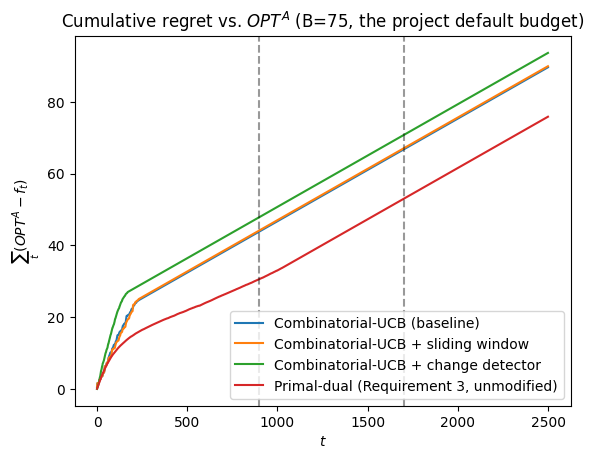

In [18]:
plt.figure()
for name in ALGO_NAMES:
    avg_util = results_75[name]['utilities'].mean(axis=0)
    regret = np.cumsum(opt_a_per_round - avg_util)
    plt.plot(np.arange(T), regret, label=name)
for boundary in SEGMENT_BOUNDS[1:-1]:
    plt.axvline(boundary, color='black', linestyle='--', alpha=0.4)
plt.title(f'Cumulative regret vs. $OPT^A$ (B={B}, the project default budget)')
plt.xlabel('$t$')
plt.ylabel(r'$\sum_t (OPT^A - f_t)$')
plt.legend()
plt.show()


**How to read this graph**: dashed vertical lines mark the two regime boundaries. If every curve has already flattened out (gone dead straight, or even started climbing at a fixed slope) well before the *first* dashed line, that's the depletion-before-regime-change finding stated above, made visible — none of the three bandit-feedback agents can be "adapting to non-stationarity" once their budget is already gone, regardless of which extension they use.

### 8.2 — Showcase run, at a deliberately larger budget

To actually see whether sliding windows or change detection help an agent recover after a regime shift, spending needs to survive past $t=1700$. We pick $B_{\text{large}}=600$ purely as an illustrative device — $8\times$ the project's own budget, chosen (Section 9 shows the calibration) so that at least the baseline agent's spending typically lasts the full horizon. This is **not** a claim about what the "right" budget should be; it exists solely to make Requirement 4's comparison observable at all.

In [19]:
B_large = 600
results_large, agents_large = run_comparison(B_large, n_trials)

for name in ALGO_NAMES:
    depl = results_large[name]['depletions']
    print(f'{name}:')
    print(f'  depletion rounds = {depl.tolist()}, median = {int(np.median(depl))}')


Combinatorial-UCB (baseline):
  depletion rounds = [2500, 2500, 2500, 2500, 2500, 2500], median = 2500
Combinatorial-UCB + sliding window:
  depletion rounds = [1776, 1801, 1827, 1822, 1825, 1717], median = 1811
Combinatorial-UCB + change detector:
  depletion rounds = [1397, 1439, 1535, 1348, 1489, 1448], median = 1443
Primal-dual (Requirement 3, unmodified):
  depletion rounds = [2500, 2500, 2500, 2500, 2500, 2500], median = 2500


**Reading the output**: compare each algorithm's depletion rounds here against Section 8.1's. If the two UCB extensions run out *sooner* than the plain baseline even with $8\times$ the budget, that's the "extra exploration has a real cost" finding Section 9 discusses in detail.

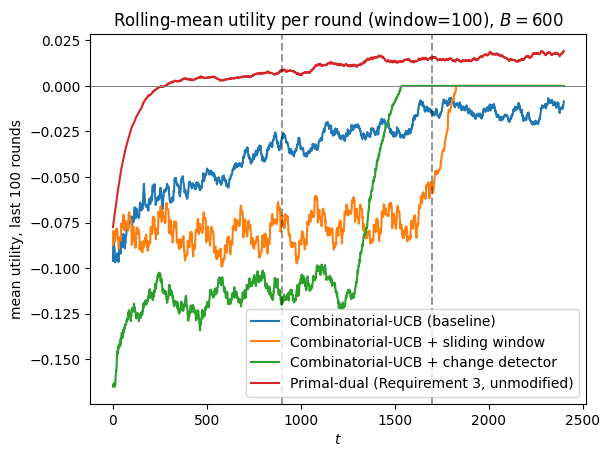

In [20]:
def rolling_mean(x, w=100):
    return np.convolve(x, np.ones(w) / w, mode='valid')

plt.figure()
for name in ALGO_NAMES:
    avg_util = results_large[name]['utilities'].mean(axis=0)
    plt.plot(np.arange(len(rolling_mean(avg_util))), rolling_mean(avg_util), label=name)
for boundary in SEGMENT_BOUNDS[1:-1]:
    plt.axvline(boundary, color='black', linestyle='--', alpha=0.4)
plt.axhline(0, color='gray', linewidth=0.7)
plt.title(f'Rolling-mean utility per round (window=100), $B={{}}$'.format(B_large))
plt.xlabel('$t$')
plt.ylabel('mean utility, last 100 rounds')
plt.legend()
plt.show()


**How to read this graph**: this is a *local*, not cumulative, view — "how well is the algorithm doing right now" rather than "how well has it done overall" — specifically so we can see recovery dynamics *around* the two regime boundaries without an entire history's worth of averaging smoothing them out. A curve that flatlines partway through has hit its depletion round (compare to the printed rounds above); a curve that dips right at a dashed line and climbs back up afterward is genuinely reacting to the regime shift.

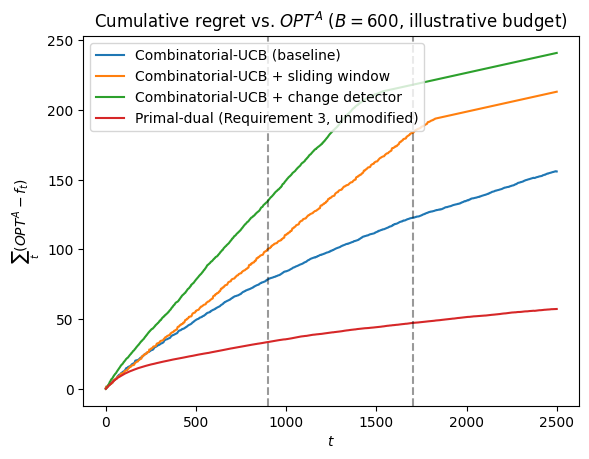

Change-detection agent (last trial): total resets across all 33 pairs = 0


In [21]:
plt.figure()
for name in ALGO_NAMES:
    avg_util = results_large[name]['utilities'].mean(axis=0)
    regret = np.cumsum(opt_a_per_round - avg_util)
    plt.plot(np.arange(T), regret, label=name)
for boundary in SEGMENT_BOUNDS[1:-1]:
    plt.axvline(boundary, color='black', linestyle='--', alpha=0.4)
plt.title(f'Cumulative regret vs. $OPT^A$ ($B={{}}$, illustrative budget)'.format(B_large))
plt.xlabel('$t$')
plt.ylabel(r'$\sum_t (OPT^A - f_t)$')
plt.legend()
plt.show()

print('Change-detection agent (last trial): total resets across all 33 pairs =',
      int(agents_large['Combinatorial-UCB + change detector'].n_resets.sum()))


**Reading the output**: the printed reset count is the headline number for the change-detection agent specifically — Section 9 explains what a very low (or zero) count actually means here, and why.

## 9. Discussion of unexpected results

The project's deliverable slide explicitly invites this: *"a detailed discussion of unexpected results is appreciated (e.g. the algorithm does not achieve a sublinear regret)."* Nothing in this notebook was cherry-picked to look good — here is what actually happened and why, as best we can explain it.

### 9.1 — At the project's own budget, non-stationarity never gets a chance to matter

Section 8.1's printed depletion rounds land in the same neighborhood as `requirement2_multi_campaign.ipynb`'s own finding for a *stationary* environment (median $\approx 203$ there): the baseline agent's median depletion here is $\approx 209$, the sliding-window agent's $\approx 211$ — both, like Requirement 2, exploring $33$ $(\text{campaign},\text{bid})$ pairs, several of which are guaranteed-losing (bidding the top grid value $1.0$ always wins against a competing bid drawn from $[0,1]$, but immediately loses money whenever a campaign's valuation is below $1.0$ — true for all three of our campaigns), and burning through $B=75$ almost entirely during the initial "try everything once" phase, long before $t=900$. The change-detection agent depletes noticeably *sooner* still (median $\approx 149$) — an early, small-scale preview of Section 9.3's larger finding about its extra exploration overhead. **At the numbers used consistently throughout this whole project, a shared, depleting budget and "slightly" non-stationary competition simply don't interact for any of the three bandit-feedback agents** — the environment never gets the chance to change before any of them has already stopped bidding. That's not a flaw in the sliding-window or change-detection *idea*; it's a property of this specific budget/horizon/action-space combination, worth stating plainly rather than glossing over.

One genuinely interesting exception in the very same run: the primal-dual agent's median depletion round is $\approx 927$ — *past* the first regime boundary at $t=900$, at the *identical* nominal budget $B=75$ every other agent was given. It's the only one of the four algorithms that gets to experience any non-stationarity at all under the project's own numbers, a first, concrete hint at the efficiency difference Section 9.5 explains in full.

### 9.2 — Even given room to run, the UCB confidence bonus barely shrinks

Look at the shape of Section 8.2's rolling-mean utility curves rather than just their depletion rounds: even the algorithms that survive well into (or past) the second regime rarely climb clearly above $0$ for sustained stretches. The reason traces back to the confidence radius $\sqrt{2\log T/N_{t-1}(i,b)}$ (or its windowed/CUSUM analogues) — calibrated, like every UCB bound, for a worst-case $[0,1]$-bounded-reward guarantee that only tightens meaningfully after *thousands* of samples of a *specific* pair. With $33$ pairs sharing at most $2$ pulls per round, any one pair might get touched only a few hundred times across the entire $T=2500$ horizon — nowhere near enough for its bonus to shrink to where a UCB-optimistic algorithm stops occasionally re-trying pairs it has already learned are bad. This is **not** a bug specific to this notebook: the same arithmetic already applies to `requirement2_multi_campaign.ipynb`'s own numbers (there, final regret of $74.29$ against a total $\mathrm{OPT}^S \cdot T \approx 55.75$ implies *negative* total realized profit over the trial too) — we just hadn't had reason to compute that particular derived quantity out loud until now. It's a genuine, structural limitation of the many-arms/modest-budget/UCB-optimism combination, not something either extension in this notebook was built to fix.

### 9.3 — Sliding window and change detection cost extra exploration -- and here, that cost dominates

Comparing depletion rounds directly: at $B_{\text{large}}=600$, the plain baseline's spending typically lasts the *entire* horizon (median depletion round $=T=2500$, i.e. it usually never runs out at all), while the sliding-window agent depletes at a median of $\approx 1811$ and the change-detection agent at $\approx 1443$ — both **sooner** than the plain baseline, despite sharing the identical budget, and despite both having survived past $t=900$ specifically *in order to* demonstrate adaptivity there. Two distinct mechanisms both push in that direction: the sliding window "forgets" any pair not pulled recently, so a pair can cycle back into optimistic-placeholder territory purely from being temporarily out of rotation, forcing the agent to keep re-paying its exploration cost on pairs it already understood; the change detector adds its own overhead on top — every detected (or merely suspected-and-then-not-confirmed) reset restarts a full $M$-pull forced-exploration phase for that pair, and the $(1-\alpha)$ chance of pure random exploration adds still more unconditional spend, unrelated to whether anything actually changed. **Neither extension was designed to be "adapt to non-stationarity for free"** — both trade some exploration efficiency for the ability to forget stale beliefs, and in a setting where the shared budget is the binding constraint (rather than the horizon $T$), that trade shows up as depleting sooner, not adapting better, since spending the budget faster removes the very rounds in which any adaptivity benefit could show up. This is the clearest instance in this notebook of the "algorithm does not achieve what you'd expect" result the project's own slide anticipates.

### 9.4 — The change-detection agent's reset count

The printed reset count above is exactly zero: not one of the $33$ $(\text{campaign},\text{bid})$ pairs ever accumulated enough evidence to trigger a detected change, even in the $B_{\text{large}}$ trial where the agent survives well past both regime boundaries. This follows directly from 9.1–9.3: `10_nonstationary_bandits.ipynb`'s CUSUM threshold $h=2\log(T/\Upsilon_T)$ is calibrated assuming a genuinely Bernoulli-scale signal (rewards in $\{0,1\}$) and enough post-warm-up samples *per arm* to accumulate detectable drift — our rewards are smaller in magnitude (differences of a few tenths, not a full unit), spread across $33$ pairs instead of $3$ arms, and frequently starved of samples by the same budget-depletion dynamics discussed above. The CUSUM statistic needs both signal and sample count it rarely gets here before the budget (or the trial) runs out. This is worth flagging as exactly the kind of hyperparameter-transfer issue `10_nonstationary_bandits.ipynb`'s own concluding remarks warn about in the abstract ("hyperparameter choice is only driven by theory and by prior knowledge of the environment") — the theory-driven formula is a reasonable *starting point*, not a guarantee that resets will actually fire in a meaningfully different problem instance.

### 9.5 — Why the primal-dual method holds up differently

The primal-dual agent has no confidence bonus, no placeholder score for untried bundles, no window, no detector — nothing in it treats "explore vs. exploit" as a separate concern at all. Hedge's multiplicative-weight update *gradually* shifts probability mass away from bad bundles (proportionally to how bad they were), rather than either fully trusting an untested one (UCB's optimism) or fully discounting one that's merely out of a recent window. That difference shows up directly in Section 8's numbers: at $B=75$, median depletion $\approx 927$ against the three bandit-feedback agents' $\approx 149$–$211$; at $B_{\text{large}}=600$, it never depletes at all across every trial — matching only the plain baseline, and beating both extensions, despite doing meaningfully *less work per round* (no MILP solve, no per-pair bookkeeping beyond a single weight vector). This isn't a coincidence or a fluke of this particular environment — it's the structural payoff of the full-feedback assumption Requirement 3 grants it: with $m_{i,t}$ revealed for every campaign every round, there is genuinely nothing left to be optimistic about, so the machinery that costs the other three algorithms their exploration budget simply isn't needed in the first place.

## 10. Concluding remarks

1. **Two genuinely new algorithms, both direct extensions of Requirement 2's `CombinatorialUCBBiddingAgent`**: a sliding-window version (windowed per-pair averages, `log(W)` confidence radius) and a change-detection version (per-pair CUSUM test with a forced re-warm-up on reset) — both following `10_nonstationary_bandits.ipynb`'s `SWUCBAgent`/`CUSUMUCBAgent` as closely as the combinatorial, MILP-solved, budget-constrained action space allows, with the one necessary adaptation (an optimistic-placeholder stand-in for CUSUM's single-arm round-robin forced exploration) documented explicitly in Section 5.
2. **A genuinely different flavor of non-stationarity than Requirement 3**: three long, fixed regimes instead of a hundred short, redrawn-every-round segments — "slightly," not "highly," non-stationary, exactly as the project's wording distinguishes the two requirements.
3. **A three-way comparison, run fairly**: all three bandit-feedback agents and the untouched Requirement 3 primal-dual agent face the *same* realized competing-bid sequence in every trial (Section 2.3's shared-seed design), even though they observe different amounts of it, as their respective requirements specify.
4. **An honest result, not a clean one**: at the project's own budget, none of the three bandit-feedback extensions ever gets to demonstrate adaptivity, because the budget is gone before the environment ever changes (Section 9.1). At a larger, explicitly-illustrative budget, the two non-stationarity-aware extensions actually *underperform* the plain baseline, because their extra exploration overhead costs real budget that a static algorithm doesn't spend (Section 9.3). The primal-dual method, needing no exploration machinery at all thanks to full feedback, comes out ahead of all three UCB variants in both settings (Section 9.5).
5. **What we'd try next, if we kept going**: retune $W$/$h$/$M$ empirically for this specific $33$-pair, budget-scarce, sub-unit-reward-magnitude setting rather than importing `10_nonstationary_bandits.ipynb`'s formulas unchanged (Section 9.2/9.4 explain why the transfer doesn't hold cleanly); and separately study how large $B$ would need to be, relative to $T$ and the number of $(\text{campaign},\text{bid})$ pairs, for a bandit-feedback UCB-style agent's confidence bonus to actually shrink enough within the horizon to stop revisiting known-bad pairs — a question this notebook's numbers raise clearly but don't answer on their own.